In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



In [6]:
# ==============================
# Excel workbook
# ==============================
excel_file = "Loss.xlsx"

sheets = {
    "BCE": "BCE",
    "Dice": "Dice",
    "Tversky": "Tversky",
    "TverskyDice": "Dice + Tversky",
    "DiceBCE": "BCE + Dice"
}


In [7]:
# ==============================
# Compute F1 and IoU
# ==============================
def add_f1_iou(df):
    eps = 1e-7

    df["val_f1"] = (
        2 * df["val_precision"] * df["val_recall"]
    ) / (
        df["val_precision"] + df["val_recall"] + eps
    )

    df["val_iou"] = df["val_f1"] / (2 - df["val_f1"] + eps)

    return df

In [10]:
# ==============================
# Read each sheet and get best epoch
# ==============================
summary = []

for sheet, loss_name in sheets.items():
    df = pd.read_excel(excel_file, sheet_name=sheet)
    df = add_f1_iou(df)

    best_idx = df["val_iou"].idxmax()

    summary.append({
        "Loss Function": loss_name,
        "Best Epoch": df.loc[best_idx, "epoch"],
        "IoU": df.loc[best_idx, "val_iou"],
        "Precision": df.loc[best_idx, "val_precision"],
        "Recall": df.loc[best_idx, "val_recall"]
    })

summary_df = pd.DataFrame(summary)

print(summary_df)

    Loss Function  Best Epoch       IoU  Precision    Recall
0             BCE          17  0.678184   0.836052  0.782211
1            Dice          37  0.697108   0.812187  0.831079
2         Tversky          37  0.664958   0.855002  0.749476
3  Dice + Tversky          30  0.685692   0.814392  0.812697
4      BCE + Dice          28  0.698214   0.824576  0.820021


    Loss Function  Best Epoch       IoU  Precision    Recall
0             BCE          17  0.678184   0.836052  0.782211
1            Dice          37  0.697108   0.812187  0.831079
2         Tversky          37  0.664958   0.855002  0.749476
3  Dice + Tversky          30  0.685692   0.814392  0.812697
4      BCE + Dice          28  0.698214   0.824576  0.820021
Index(['Loss Function', 'Best Epoch', 'IoU', 'Precision', 'Recall'], dtype='object')
    Loss Function       IoU  Precision    Recall
0             BCE  0.678184   0.836052  0.782211
1            Dice  0.697108   0.812187  0.831079
2         Tversky  0.664958   0.855002  0.749476
3  Dice + Tversky  0.685692   0.814392  0.812697
4      BCE + Dice  0.698214   0.824576  0.820021


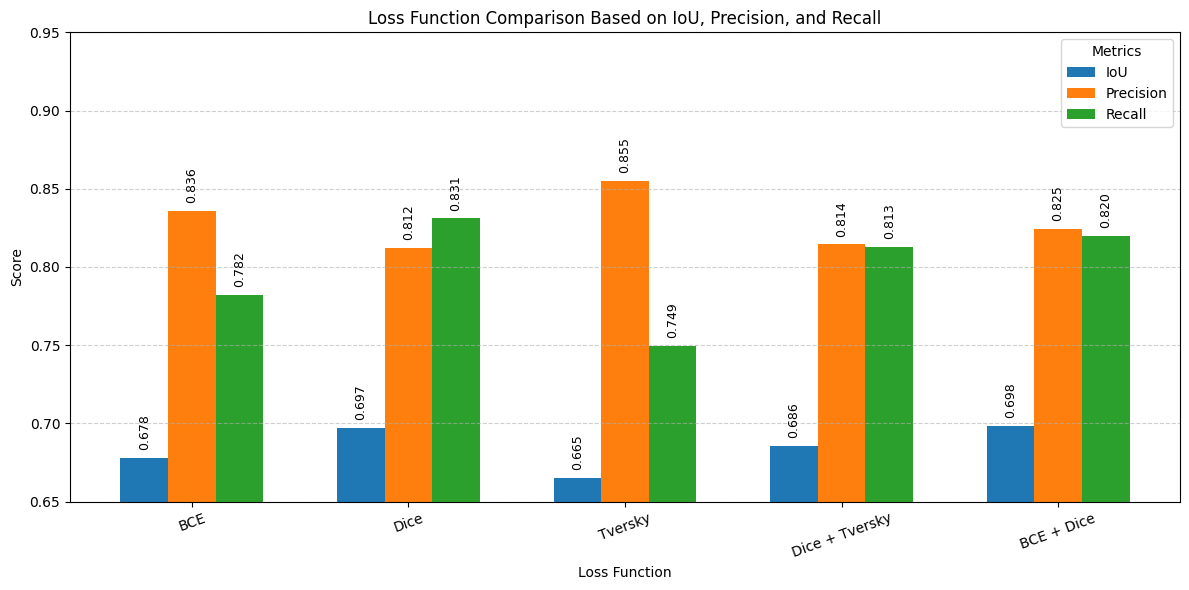

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Check columns and values
print(summary_df)
print(summary_df.columns)

# Make sure numeric
for col in ["IoU", "Precision", "Recall"]:
    summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

print(summary_df[["Loss Function", "IoU", "Precision", "Recall"]])

# ==============================
# Plot IoU, Precision, Recall
# ==============================
metrics = ["IoU", "Precision", "Recall"]

x = np.arange(len(summary_df["Loss Function"]))
width = 0.22

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    bars = plt.bar(
        x + (i - 1) * width,
        summary_df[metric],
        width,
        label=metric
    )

    # Add values on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            rotation=90
        )

plt.xlabel("Loss Function")
plt.ylabel("Score")
plt.title("Loss Function Comparison Based on IoU, Precision, and Recall")

plt.xticks(
    x,
    summary_df["Loss Function"],
    rotation=20
)

# Lower y-limit so IoU bars are visible
plt.ylim(0.65, 0.95)

plt.legend(title="Metrics")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig("Loss_Function_Comparison.png", dpi=300, bbox_inches="tight")
plt.savefig("Loss_Function_Comparison.pdf", bbox_inches="tight")

plt.show()